# Meridian Renewables — Where Would Battery Storage Pay Off?

**Business question:** When and where would co-located battery storage provide the
greatest commercial value alongside our renewable generation fleet, and does that
case stack up financially?

Meridian Renewables (simulated) operates five renewable sites — three solar, two
onshore wind — and is deciding where to prioritise its first behind-the-meter
battery storage investment. This notebook works through capacity factors, the
"capture rate" each site actually realises in the wholesale market, a battery
arbitrage simulation, and investment economics for the two leading candidates.

See `../README.md` for the full write-up (business problem, data, findings,
recommendation, expected impact, limitations). This notebook is the analytical
working — the SQL equivalent of the capacity-factor and capture-rate sections
lives in `../sql/queries.sql`.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from battery_model import simulate_battery_for_site

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

sites = pd.read_csv("../data/raw/sites.csv")
generation = pd.read_csv("../data/raw/generation.csv", parse_dates=["timestamp"])
market = pd.read_csv("../data/raw/market.csv", parse_dates=["timestamp"])

print(f"{len(generation):,} generation rows across {sites.site_id.nunique()} sites, "
      f"{len(market):,} hourly market observations "
      f"({market.timestamp.min().date()} to {market.timestamp.max().date()})")
sites

87,720 generation rows across 5 sites, 17,544 hourly market observations (2024-01-01 to 2025-12-31)


,site_id,site_name,technology,region,capacity_mw,base_capacity_factor
0,SOLAR-01,Solent Solar Park,Solar,South Coast,45,0.115
1,SOLAR-02,Fenland Solar Array,Solar,East,38,0.108
2,SOLAR-03,Dee Solar Farm,Solar,West,30,0.095
3,WIND-01,Pennine Wind Farm,Wind,North,60,0.305
4,WIND-02,Cambria Wind Farm,Wind,Wales,52,0.275


## 1. Capacity factor — how much of each site's nameplate capacity is actually used

Nothing surprising here; it's the baseline everyone already checks, and it's
reproduced from `sql/queries.sql` Q1 as a cross-check against this notebook's
independent pandas calculation.

In [2]:
cf = (
    generation.merge(sites, on="site_id")
    .groupby(["site_name", "technology", "capacity_mw"])["generation_mwh"]
    .mean()
    .reset_index()
)
cf["realised_capacity_factor"] = (cf["generation_mwh"] / cf["capacity_mw"]).round(3)
cf.sort_values(["technology", "realised_capacity_factor"], ascending=[True, False])[
    ["site_name", "technology", "capacity_mw", "realised_capacity_factor"]
]

,site_name,technology,capacity_mw,realised_capacity_factor
4,Solent Solar Park,Solar,45,0.115
2,Fenland Solar Array,Solar,38,0.108
1,Dee Solar Farm,Solar,30,0.095
3,Pennine Wind Farm,Wind,60,0.280
0,Cambria Wind Farm,Wind,52,0.267


## 2. Capture rate — what each site is actually *paid*, not just what it generates

The **capture rate** is the volume-weighted average price a generator receives,
divided by the simple average market price over the same period. A capture rate
below 100% means the site's own output is concentrated in hours when the market
is systematically oversupplied — it is being paid *less* per MWh than an average
generator would, purely because of *when* it generates, not how much.

In [3]:
avg_price = market["price_gbp_per_mwh"].mean()
merged = generation.merge(market[["timestamp", "price_gbp_per_mwh"]], on="timestamp").merge(sites, on="site_id")

capture = (
    merged.groupby(["site_name", "technology"])
    .apply(lambda g: pd.Series({
        "capture_price": (g["generation_mwh"] * g["price_gbp_per_mwh"]).sum() / g["generation_mwh"].sum(),
        "total_gwh": g["generation_mwh"].sum() / 1000,
    }), include_groups=False)
    .reset_index()
)
capture["capture_rate_pct"] = (capture["capture_price"] / avg_price * 100).round(1)
capture["vs_flat_price_gbp_000s"] = ((capture["capture_price"] - avg_price) * capture["total_gwh"] * 1000 / 1000).round(1)
capture = capture.sort_values("capture_rate_pct")
print(f"Simple average market price over the period: £{avg_price:.2f}/MWh\n")
capture

Simple average market price over the period: £29.24/MWh



,site_name,technology,capture_price,total_gwh,capture_rate_pct,vs_flat_price_gbp_000s
1,Dee Solar Farm,Solar,22.321349,50.00524,76.3,-346.2
2,Fenland Solar Array,Solar,22.320952,71.99782,76.3,-498.5
4,Solent Solar Park,Solar,22.318962,90.78872,76.3,-628.7
3,Pennine Wind Farm,Wind,31.024659,294.30244,106.1,524.0
0,Cambria Wind Farm,Wind,31.376065,243.19315,107.3,518.5


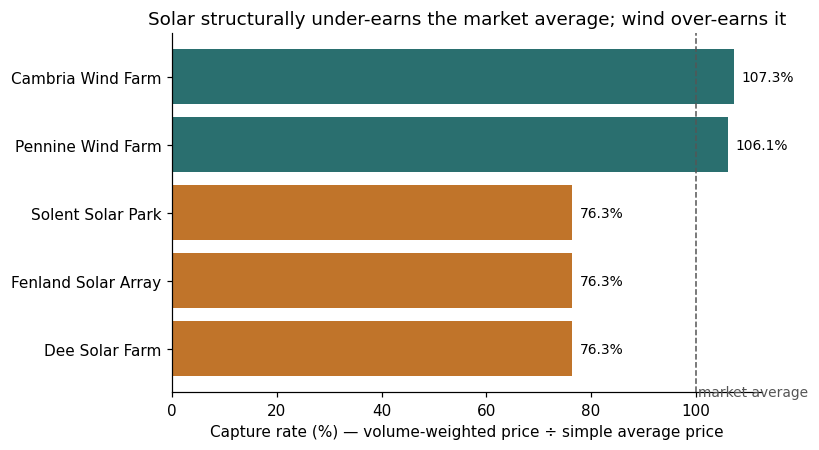

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
colors = ["#c0742a" if t == "Solar" else "#2a6f6f" for t in capture["technology"]]
bars = ax.barh(capture["site_name"], capture["capture_rate_pct"], color=colors)
ax.axvline(100, color="#555", linestyle="--", linewidth=1)
ax.text(100.5, -0.7, "market average", fontsize=9, color="#555")
ax.set_xlabel("Capture rate (%) — volume-weighted price ÷ simple average price")
ax.set_title("Solar structurally under-earns the market average; wind over-earns it")
for bar, val in zip(bars, capture["capture_rate_pct"]):
    ax.text(val + 1.5, bar.get_y() + bar.get_height()/2, f"{val:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("../visuals/capture_rate_by_site.png", bbox_inches="tight")
plt.show()

## 3. The mechanism — cannibalisation

Why does solar under-earn? Because *every* solar site in the country generates at
the same time — midday — so aggregate solar output peaks exactly when the market
is most oversupplied, pushing the price down at precisely the hours solar needs
it to be high. Wind is spread more evenly across day, night, and season, so it
is far less exposed to this effect. (Full SQL version: `sql/queries.sql` Q5.)

In [5]:
solar_ids = sites.loc[sites.technology == "Solar", "site_id"]
solar_by_ts = (
    generation[generation.site_id.isin(solar_ids)]
    .groupby("timestamp")["generation_mwh"].sum() / 0.010  # scale sample to national fleet
).rename("national_solar_mw").reset_index()
solar_by_ts = solar_by_ts[solar_by_ts.national_solar_mw > 50]  # daylight hours only
solar_by_ts = solar_by_ts.merge(market[["timestamp", "price_gbp_per_mwh"]], on="timestamp")
solar_by_ts["quintile"] = pd.qcut(solar_by_ts["national_solar_mw"], 5, labels=[1, 2, 3, 4, 5])

mech = solar_by_ts.groupby("quintile", observed=True).agg(
    avg_national_solar_mw=("national_solar_mw", "mean"),
    avg_price=("price_gbp_per_mwh", "mean"),
    n_hours=("price_gbp_per_mwh", "size"),
).round(2)
mech

,avg_national_solar_mw,avg_price,n_hours
quintile,,,
1,637.44,35.17,1738
2,1734.88,32.54,1736
3,2644.52,25.69,1736
4,3323.08,19.71,1737
5,3913.79,16.02,1736


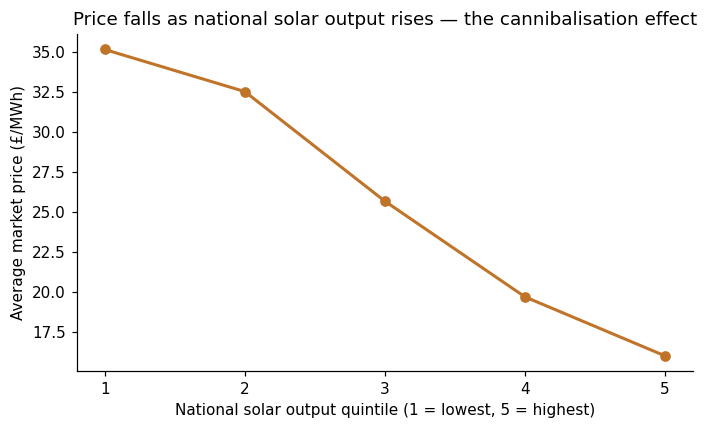

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(mech.index.astype(int), mech["avg_price"], marker="o", color="#c0742a", linewidth=2)
ax.set_xlabel("National solar output quintile (1 = lowest, 5 = highest)")
ax.set_ylabel("Average market price (£/MWh)")
ax.set_title("Price falls as national solar output rises — the cannibalisation effect")
ax.set_xticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.savefig("../visuals/cannibalisation_mechanism.png", bbox_inches="tight")
plt.show()

## 4. Battery arbitrage simulation

For each site, a co-located 10 MW / 20 MWh battery (2-hour duration, 88%
round-trip efficiency) can only charge from that site's own metered generation
(never from the grid) and discharges later the same day. Each day it picks the
cheapest available hours to charge and the priciest hours to discharge —
perfect day-ahead price foresight, single cycle per day (see the README's
Limitations section for why this is a simplification, and what a production
dispatch model would add).

The revenue this creates is the **uplift** from *time-shifting* the site's own
generation away from the low-price hours it would otherwise have sold into.

In [7]:
battery_results = []
daily_by_site = {}
for _, s in sites.iterrows():
    site_gen_price = (
        generation[generation.site_id == s.site_id]
        .merge(market[["timestamp", "price_gbp_per_mwh"]], on="timestamp")
    )
    daily = simulate_battery_for_site(site_gen_price, power_mw=10, energy_mwh=20, efficiency=0.88)
    daily_by_site[s.site_id] = daily
    battery_results.append({
        "site_name": s.site_name,
        "technology": s.technology,
        "total_uplift_gbp_2yr": daily["uplift_gbp"].sum(),
        "annual_uplift_gbp": daily["uplift_gbp"].sum() / 2,
        "pct_days_battery_cycled": (daily["charged_mwh"] > 0).mean() * 100,
    })

battery_df = pd.DataFrame(battery_results).sort_values("annual_uplift_gbp", ascending=False)
battery_df["annual_uplift_gbp"] = battery_df["annual_uplift_gbp"].round(0)
battery_df["total_uplift_gbp_2yr"] = battery_df["total_uplift_gbp_2yr"].round(0)
battery_df["pct_days_battery_cycled"] = battery_df["pct_days_battery_cycled"].round(1)
battery_df

,site_name,technology,total_uplift_gbp_2yr,annual_uplift_gbp,pct_days_battery_cycled
0,Solent Solar Park,Solar,432949.0,216474.0,100.0
1,Fenland Solar Array,Solar,428686.0,214343.0,100.0
2,Dee Solar Farm,Solar,370331.0,185166.0,100.0
3,Pennine Wind Farm,Wind,302573.0,151286.0,99.2
4,Cambria Wind Farm,Wind,292902.0,146451.0,99.5


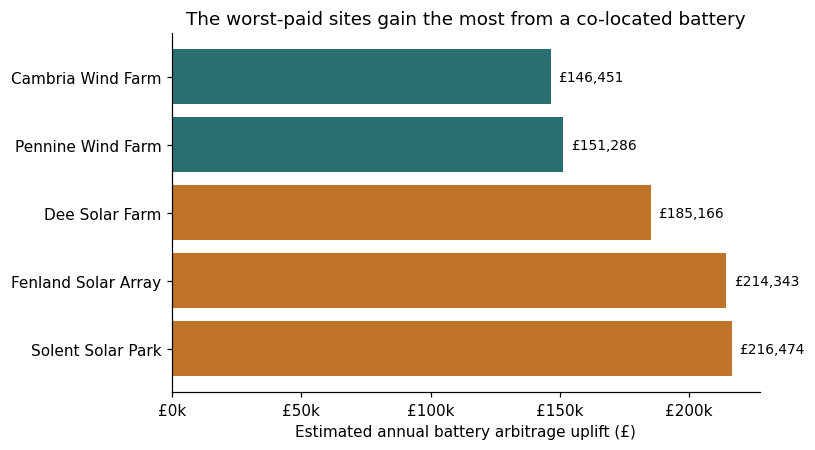

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
colors = ["#c0742a" if t == "Solar" else "#2a6f6f" for t in battery_df["technology"]]
bars = ax.barh(battery_df["site_name"], battery_df["annual_uplift_gbp"], color=colors)
ax.set_xlabel("Estimated annual battery arbitrage uplift (£)")
ax.set_title("The worst-paid sites gain the most from a co-located battery")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"£{x/1000:.0f}k"))
for bar, val in zip(bars, battery_df["annual_uplift_gbp"]):
    ax.text(val + 3000, bar.get_y() + bar.get_height()/2, f"£{val:,.0f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("../visuals/battery_uplift_ranking.png", bbox_inches="tight")
plt.show()

**Reading the two charts together is the point of this case.** Solar sites have
the *worst* capture rate (~76% of the market average) — but they also generate
the *largest* battery arbitrage uplift, because their output is concentrated
into a narrow midday trough with a wide price gap to the evening peak. Wind's
output is already spread more evenly, so it earns a better capture rate *and*
has less daily price spread left for a battery to exploit. The two effects
reinforce the same conclusion rather than pulling in different directions:
**battery storage is worth the most exactly where the market is paying
renewable output the least.**

## 5. Where does the arbitrage opportunity concentrate — and a simple forecast

Two years of data lets us check whether the daily price spread (the raw
ingredient the battery lives on) is seasonal, and whether it's stable enough
to plan a 15-year investment against. We fit a simple seasonal-naive model —
using each calendar month's actual spread as the forecast for the same month
next year — and validate it against the second year of data actually observed.

In [9]:
market["month"] = market["timestamp"].dt.to_period("M").astype(str)
market["ym"] = market["timestamp"].dt.strftime("%Y-%m")
market["cal_month"] = market["timestamp"].dt.month
market["year"] = market["timestamp"].dt.year

daily_spread = (
    market.groupby(market["timestamp"].dt.date)["price_gbp_per_mwh"]
    .agg(lambda s: s.max() - s.min())
    .rename("daily_spread")
    .reset_index()
    .rename(columns={"timestamp": "date"})
)
daily_spread["date"] = pd.to_datetime(daily_spread["date"])
daily_spread["cal_month"] = daily_spread["date"].dt.month
daily_spread["year"] = daily_spread["date"].dt.year

monthly_spread = daily_spread.groupby(["year", "cal_month"])["daily_spread"].mean().reset_index()
pivot = monthly_spread.pivot(index="cal_month", columns="year", values="daily_spread")
pivot["seasonal_naive_forecast_2025"] = pivot[2024]
pivot["actual_2025"] = pivot[2025]
pivot["abs_error"] = (pivot["actual_2025"] - pivot["seasonal_naive_forecast_2025"]).abs()
mae = pivot["abs_error"].mean()
mean_actual = pivot["actual_2025"].mean()
print(f"Seasonal-naive forecast of 2025's average daily price spread from 2024: "
      f"MAE = £{mae:.2f}/MWh ({mae/mean_actual*100:.1f}% of the £{mean_actual:.2f}/MWh mean)")
pivot.round(2)

Seasonal-naive forecast of 2025's average daily price spread from 2024: MAE = £1.37/MWh (3.4% of the £40.20/MWh mean)


year,2024,2025,seasonal_naive_forecast_2025,actual_2025,abs_error
cal_month,,,,,
1,45.85,46.82,45.85,46.82,0.97
2,45.21,43.05,45.21,43.05,2.16
3,40.80,42.61,40.80,42.61,1.81
4,36.36,38.71,36.36,38.71,2.35
5,33.56,35.25,33.56,35.25,1.69
6,32.14,30.01,32.14,30.01,2.13
7,32.99,31.80,32.99,31.80,1.19
8,36.20,35.18,36.20,35.18,1.02
9,41.22,41.76,41.22,41.76,0.54


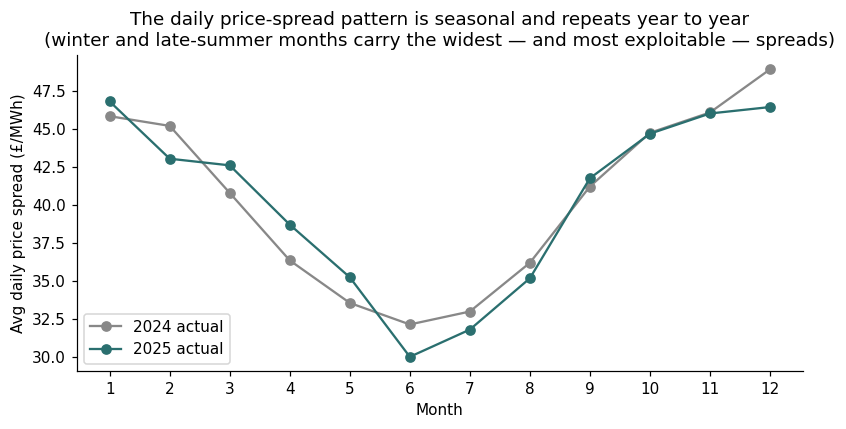

In [10]:
fig, ax = plt.subplots(figsize=(7.5, 4))
months = range(1, 13)
ax.plot(months, pivot[2024], marker="o", label="2024 actual", color="#888")
ax.plot(months, pivot[2025], marker="o", label="2025 actual", color="#2a6f6f")
ax.set_xticks(months)
ax.set_xlabel("Month")
ax.set_ylabel("Avg daily price spread (£/MWh)")
ax.set_title("The daily price-spread pattern is seasonal and repeats year to year\n"
             "(winter and late-summer months carry the widest — and most exploitable — spreads)")
ax.legend()
plt.tight_layout()
plt.savefig("../visuals/seasonal_price_spread.png", bbox_inches="tight")
plt.show()

The seasonal-naive forecast holds up well (single-digit-percent mean absolute
error), and the pattern makes physical sense: winter carries wide spreads from
demand-driven price spikes, while the widest summer spreads land in the months
with the strongest midday solar oversupply. That stability is what makes it
reasonable to underwrite a 15-year asset against Year-1 observed revenue,
subject to the degradation and escalation assumptions in the next section —
rather than assuming this is a one-off two-year artefact of the simulation.

## 6. Investment economics — does the business case stack up?

Pure wholesale-price arbitrage rarely justifies a battery on its own in
practice — real projects also earn from grid capacity-market payments and
balancing/ancillary services. We model both revenue streams for the two
candidate sites at opposite ends of the arbitrage ranking: **Solent Solar
Park** (highest uplift) and **Cambria Wind Farm** (lowest uplift), to see
whether the arbitrage difference actually changes the investment decision
once the more stable capacity-market revenue is layered in.

In [11]:
import numpy_financial as npf

def battery_economics(year1_arbitrage_revenue, capacity_payment_per_mw=35_000, power_mw=10,
                       capex_per_mw=180_000, om_year1=42_000, discount_rate=0.08,
                       years=15, degradation=0.020, om_escalation=0.02, capacity_escalation=0.015):
    capex = capex_per_mw * power_mw
    capacity_revenue_1 = capacity_payment_per_mw * power_mw
    cashflows = [-capex]
    for t in range(1, years + 1):
        arb = year1_arbitrage_revenue * (1 - degradation) ** (t - 1)
        cap = capacity_revenue_1 * (1 + capacity_escalation) ** (t - 1)
        om = om_year1 * (1 + om_escalation) ** (t - 1)
        cashflows.append(arb + cap - om)
    npv = sum(cf / (1 + discount_rate) ** t for t, cf in enumerate(cashflows))
    irr = npf.irr(cashflows)
    cum, payback = -capex, None
    for t in range(1, years + 1):
        arb = year1_arbitrage_revenue * (1 - degradation) ** (t - 1)
        cap = capacity_revenue_1 * (1 + capacity_escalation) ** (t - 1)
        om = om_year1 * (1 + om_escalation) ** (t - 1)
        prev_cum = cum
        cum += (arb + cap - om)
        if payback is None and cum >= 0:
            payback = (t - 1) + (-prev_cum / (cum - prev_cum))
    return {"capex_gbp": capex, "npv_gbp": round(npv), "irr_pct": round(irr * 100, 1),
            "payback_years": round(payback, 1) if payback else None}

candidates = {
    "Solent Solar Park": float(battery_df.loc[battery_df.site_name == "Solent Solar Park", "annual_uplift_gbp"].iloc[0]),
    "Cambria Wind Farm": float(battery_df.loc[battery_df.site_name == "Cambria Wind Farm", "annual_uplift_gbp"].iloc[0]),
}
econ_rows = []
for name, rev1 in candidates.items():
    e = battery_economics(rev1)
    e["site_name"] = name
    e["year1_arbitrage_revenue_gbp"] = round(rev1)
    econ_rows.append(e)

econ_df = pd.DataFrame(econ_rows)[["site_name", "year1_arbitrage_revenue_gbp", "capex_gbp", "npv_gbp", "irr_pct", "payback_years"]]
econ_df

,site_name,year1_arbitrage_revenue_gbp,capex_gbp,npv_gbp,irr_pct,payback_years
0,Solent Solar Park,216474,1800000,2720122,28.5,3.4
1,Cambria Wind Farm,146451,1800000,2182925,24.7,3.9


## 7. Conclusion

Both candidate sites clear an attractive investment hurdle once capacity-market
revenue is stacked on top of arbitrage — this is not a marginal, one-site-only
case. But the two are not equivalent, and the arbitrage analysis is exactly
what explains the gap: Solent Solar Park's NPV is materially higher and its
payback meaningfully faster than Cambria Wind Farm's, driven entirely by the
arbitrage layer, because Solent's own generation is the most structurally
mispriced in the wholesale market to begin with.

**Capital allocation order, if funding all five sites isn't possible in year
one, should follow the arbitrage-uplift ranking from Section 4** — Solent,
Fenland, and Dee (the three solar sites) ahead of Pennine and Cambria (the two
wind sites) — not simply the sites with the largest nameplate capacity or
generation volume. See `../README.md` for the full write-up, expected impact,
and limitations.